# CLR AND KNIFFEL USING CLASSES

In [2]:
%matplotlib inline

In [3]:
import numpy as np
import random as r
import matplotlib.pyplot as plt
import sys
from scipy.optimize import curve_fit
from scipy.stats import norm

## We will not make a Players class
#### But you could try introducing one along the lines of

"""<Python>
    
    class Players:
        nplayers = 1

        def __init__(self, nplayers=nplayers):
            self.coins = np.ndarray.zeros(nplayers)
"""

## Die class

In [4]:
class Die:
    """
    Die class

    Attributes
      1. `faces`: tuple with faces provided by the user (default is a 1-6 regular die)
    """
    
    def __init__(self, faces=(1,2,3,4,5,6)):
        self.faces = faces
    
    def single_roll(self):
        """
        Randomly returns one of the values in `faces`, with even probability.
        """
        # Slower
        #return np.random.choice(self.faces)
        # Faster
        return r.choice(self.faces)

In [5]:
help(Die)

Help on class Die in module __main__:

class Die(builtins.object)
 |  Die(faces=(1, 2, 3, 4, 5, 6))
 |
 |  Die class
 |
 |  Attributes
 |    1. `faces`: tuple with faces provided by the user (default is a 1-6 regular die)
 |
 |  Methods defined here:
 |
 |  __init__(self, faces=(1, 2, 3, 4, 5, 6))
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  single_roll(self)
 |      Randomly returns one of the values in `faces`, with even probability.
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



## Class for CLR

<img src="https://www.mpl.live/blog/wp-content/webp-express/webp-images/uploads/2022/04/Left-Center-Right-Game.jpeg.webp"  width=300 height=300 />

In [6]:
class CLR_Game():
    """
    Class to simulate a CLR game

    Attributes
      1. `nplayers`: number of players in the game; must be 3 or more [int, default: 3]
      2. `coins`: coins per player at the start of the game; must be 1 or more [int, default: 30]
      3. `names`: names of the players [list, default: None]
      4. `verbose`: regulate the verbosity of the output [bool, default: False]
    """

    _game_round = 0
    
    def __init__(self, nplayers=3, coins=30, names=None, verbose=False):
        # Troubleshoot input parameter nplayers
        try:
            self.nplayers = int(nplayers)
            if self.nplayers < 3:
                sys.exit(f"{self.nplayers} players requested, but they must be at least 3.")
        except ValueError as error:
            self.nplayers = 3
            print("CAREFUL, user, you hit this error:", error)
            print(f"{nplayers} is an invalid number of players, running with {self.nplayers} players.\n")
        # Troubleshoot input parameter coins
        try:
            self.coins = int(coins)
            if self.coins <= 0:
                sys.exit(f"{self.coins} coins assigned to each player, but these must be a positive number.")
        except ValueError as error:
            self.coins = 30
            print("CAREFUL, user, you hit this error:", error)
            print(f"{coins} is an invalid number of coins, running with {self.coins} coins.\n")
        self.verbose = bool(verbose)
        # If the user does not pick name, call players by number in the round
        self.names = [f'Player {i}' for i in np.arange(1, self.nplayers+1)] if names is None else names
        # Troubleshoot input parameter names
        if len(self.names) != self.nplayers:
            err_msg = "To provide players with names, the list of names must contain one name per player.\n"
            err_msg += f"{self.nplayers} players were requested but {len(self.names)} were provided, "
            err_msg += f"namely {self.names}"
            sys.exit(err_msg)
        if self.verbose:
            info = f"Simulating a CLR game with {self.nplayers} players.\n"
            info += f"Each player has {self.coins} coins to begin with.\n"
            info += "3 dice at most are used.\n"
            print(info)
        self._coins_per_player = np.full(self.nplayers, self.coins)
        self._die = Die(('C', 'L', 'R', '.', '.', '.'))
    
    def __str__(self):
        info = f"Round {self._game_round} - Coins status: {self._coins_per_player}, {self._coins_per_player.sum()} left"
        return info
    
    def play_a_game(self):
        """
        Simulate a CLR full game and see how many rounds it took to complete.
        """
        winner = None
        while(winner == None):
            self._game_round += 1
            winner = self._play_a_round()
        if self.verbose:
            info = f"Rounds played = {self._game_round}.\n"
            info += f"Winner: {self.names[winner]} with {self._coins_per_player[winner]} coin"
            if self._coins_per_player[winner]>1:
                info += "s" 
            info += " left.\n"
            print(info)
        return self._game_round
    
    def _play_a_round(self):
        if self.verbose:
            print(self)
        for iplayer in range(self.nplayers):
            roll = self._dice_roll(iplayer)
            [self._process_die_side(side, iplayer) for side in roll]
            winner = self._check_for_winner()
            if winner:
                break
        return winner
                
    def _dice_roll(self, iplayer):
        # A player can roll at most 3 dice
        dice_to_roll = min(3, self._coins_per_player[iplayer])
        roll = [self._die.single_roll() for i in range(dice_to_roll)]
        if self.verbose:
            if roll != []:
                print(f"\t {self.names[iplayer]} rolling: {roll}")
        return roll
    
    def _process_die_side(self, side, iplayer):
        if side != '.':
            self._coins_per_player[iplayer] -= 1
            if side == 'L':
                self._coins_per_player[iplayer-1] += 1
            elif side == 'R':
                self._coins_per_player[iplayer+1-self.nplayers] += 1
                
    def _check_for_winner(self):
        winner = None
        if len(self._coins_per_player.nonzero()[0]) == 1:
            winner = self._coins_per_player.argmax()
        return winner

In [7]:
help(CLR_Game)

Help on class CLR_Game in module __main__:

class CLR_Game(builtins.object)
 |  CLR_Game(nplayers=3, coins=30, names=None, verbose=False)
 |
 |  Class to simulate a CLR game
 |
 |  Attributes
 |    1. `nplayers`: number of players in the game; must be 3 or more [int, default: 3]
 |    2. `coins`: coins per player at the start of the game; must be 1 or more [int, default: 30]
 |    3. `names`: names of the players [list, default: None]
 |    4. `verbose`: regulate the verbosity of the output [bool, default: False]
 |
 |  Methods defined here:
 |
 |  __init__(self, nplayers=3, coins=30, names=None, verbose=False)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __str__(self)
 |      Return str(self).
 |
 |  play_a_game(self)
 |      Simulate a CLR full game and see how many rounds it took to complete.
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance

### Simulation of a single CLR game

In [8]:
%%time

game = CLR_Game(3, 20, verbose=True, names=['Aldo', 'Giovanni', 'Giacomo'])
game.play_a_game()

Simulating a CLR game with 3 players.
Each player has 20 coins to begin with.
3 dice at most are used.

Round 1 - Coins status: [20 20 20], 60 left
	 Aldo rolling: ['.', '.', '.']
	 Giovanni rolling: ['.', 'R', '.']
	 Giacomo rolling: ['.', '.', '.']
Round 2 - Coins status: [20 19 21], 60 left
	 Aldo rolling: ['C', 'C', 'R']
	 Giovanni rolling: ['L', '.', '.']
	 Giacomo rolling: ['.', '.', 'C']
Round 3 - Coins status: [18 19 20], 57 left
	 Aldo rolling: ['.', '.', '.']
	 Giovanni rolling: ['L', 'R', 'C']
	 Giacomo rolling: ['L', 'R', 'C']
Round 4 - Coins status: [20 17 18], 55 left
	 Aldo rolling: ['.', 'L', 'L']
	 Giovanni rolling: ['.', 'R', 'C']
	 Giacomo rolling: ['.', 'C', 'R']
Round 5 - Coins status: [19 15 19], 53 left
	 Aldo rolling: ['R', 'L', '.']
	 Giovanni rolling: ['.', '.', 'C']
	 Giacomo rolling: ['.', '.', '.']
Round 6 - Coins status: [17 15 20], 52 left
	 Aldo rolling: ['L', '.', 'R']
	 Giovanni rolling: ['.', 'L', 'L']
	 Giacomo rolling: ['L', 'R', '.']
Round 7 - Coin

39

### Simulation of `Total_games` CLR games

In [9]:
%%time

Total_games = int(1e5)
all_rounds_played_for_winner = np.array([CLR_Game(3, 20).play_a_game() for i in range(Total_games)])

CPU times: user 1min 41s, sys: 667 ms, total: 1min 42s
Wall time: 1min 44s


### Plotting the density distribution of the total rolls over the simulated games

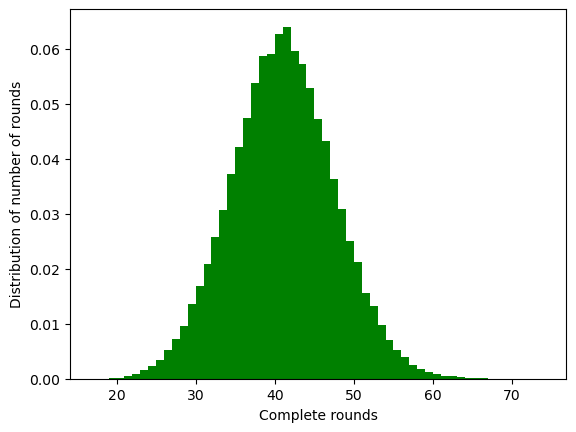

In [10]:
plt.xlabel("Complete rounds")
plt.ylabel("Distribution of number of rounds")
n, bins, patches = plt.hist(all_rounds_played_for_winner,
                            bins=max(all_rounds_played_for_winner)-min(all_rounds_played_for_winner),
                            facecolor='green', density=True, log=False)

### Fitting this distributions

This looks like a distribution to be fitted with a Gaussian.

The expectation value and standard deviation are first determined with `numpy` and `scipy.stats.norm`.  These values are then used as initial guesses for a fit with `curve_fit`.  Finally the fitted Gaussian distributions are overlayed to the histogram.

In [11]:
# Fit with numpy
param_labels = ['mu', 'sigma']

fit_pars = [np.mean(all_rounds_played_for_winner), np.std(all_rounds_played_for_winner)]

[print(f"{param_labels[i]} = {fit_pars[i]: .5f}") for i in range(2)];

mu =  40.52737
sigma =  6.48236


In [12]:
# Fit with scipy.stats.norm
param_labels = ['mu', 'sigma']

fit_pars = list(norm.fit(all_rounds_played_for_winner))
[print(f"{param_labels[i]} = {fit_pars[i]: .5f}") for i in range(2)];

mu =  40.52737
sigma =  6.48236


In [13]:
# Fit with curve_fit
param_labels = ['mu', '1/sigma', 'A']

def gauss(x, m, s_inv):
    N = s_inv / (np.sqrt(2. * np.pi))
    return N * np.exp(-0.5 * (s_inv * (x - m))**2)

x_data = np.array([(bins[i+1] + bins[i])*0.5 for i in range(n.shape[0])])
y_data = n

fit_pars, cov_matrix = curve_fit(gauss, x_data, y_data, p0=[40., 1/6.5])

[print(f"{param_labels[i]} = {fit_pars[i]: .5f} +/- {np.sqrt(cov_matrix[i,i]): .5f}") for i in range(len(fit_pars))];

mu =  40.97366 +/-  0.02578
1/sigma =  0.15514 +/-  0.00051


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8171/1662526600.py:20: SyntaxWarning: invalid escape sequence '\m'
  title = f"Total number of simulated CLR games: {Total_games}\n $\mu$={mu: .0f} and $\sigma$={1/sigma: .1f}"
/tmp/ipykernel_8171/1662526600.py:20: SyntaxWarning: invalid escape sequence '\s'
  title = f"Total number of simulated CLR games: {Total_games}\n $\mu$={mu: .0f} and $\sigma$={1/sigma: .1f}"


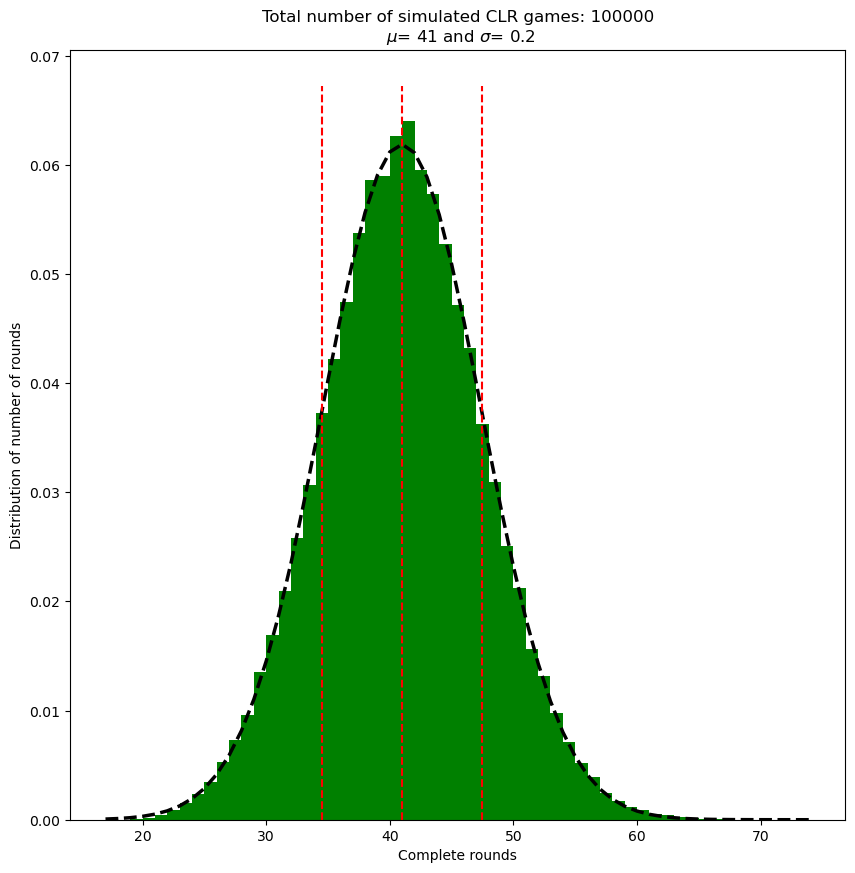

In [14]:
fig = plt.figure(figsize=(10,10))

plt.xlabel("Complete rounds")
plt.ylabel("Distribution of number of rounds")
n, bins, patches = plt.hist(
    all_rounds_played_for_winner,
    bins=max(all_rounds_played_for_winner)-min(all_rounds_played_for_winner),
    facecolor='green',
    density=True,
    log=False)

mu = fit_pars[0]
sigma_inv = fit_pars[1]
sigma = 1/sigma_inv

y = [gauss(b, mu, sigma_inv) for b in bins]
    
# replace with y = [gauss(b, mu, sigma_inv) for b in bins]

title = f"Total number of simulated CLR games: {Total_games}\n $\mu$={mu: .0f} and $\sigma$={1/sigma: .1f}"

plt.title(title)

plt.plot(bins, y, 'k--', linewidth=2.5, label='Fit')

plt.vlines(mu, 0, 1.05*max(n), ls='--', color='red')
plt.vlines(mu-sigma, 0, 1.05*max(n), ls='--', color='red')
plt.vlines(mu+sigma, 0, 1.05*max(n), ls='--', color='red')
plt.show()

Its log-linear version

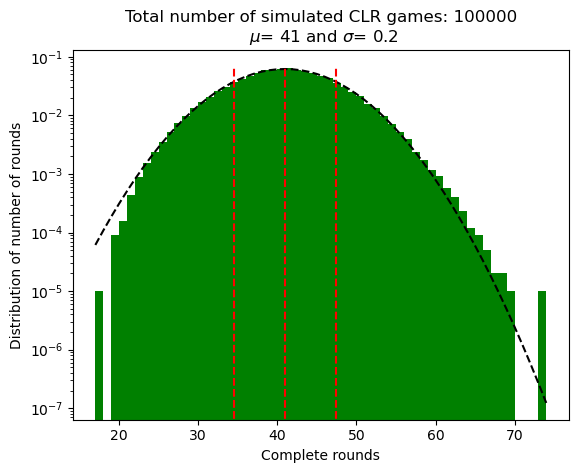

In [15]:
plt.xlabel("Complete rounds")
plt.ylabel("Distribution of number of rounds")
n, bins, patches = plt.hist(all_rounds_played_for_winner,
                            bins=max(all_rounds_played_for_winner)-min(all_rounds_played_for_winner),
                            facecolor='green', density=True, log=True)

plt.title(title)

plt.plot(bins, y, 'k--', linewidth=1.5, label='Theoretical')

plt.vlines(mu, 0, 1.05*max(n), ls='--', color='red')
plt.vlines(mu-sigma, 0, 1.05*max(n), ls='--', color='red')
plt.vlines(mu+sigma, 0, 1.05*max(n), ls='--', color='red')
plt.show()

The cumulative distribution

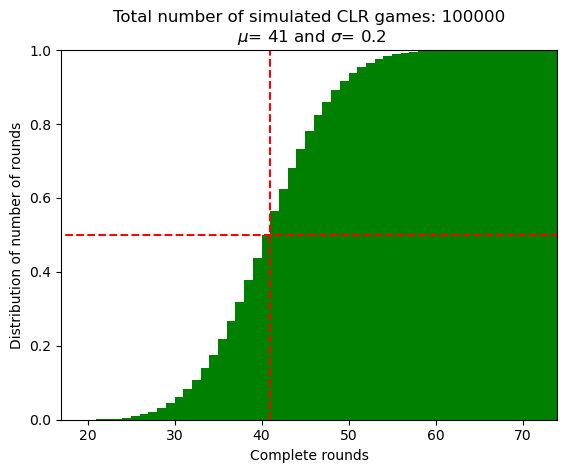

In [16]:
plt.xlabel("Complete rounds")
plt.ylabel("Distribution of number of rounds")
plt.title(title)

n, bins, patches = plt.hist(all_rounds_played_for_winner,
                            bins=max(all_rounds_played_for_winner)-min(all_rounds_played_for_winner),
                            facecolor='green', density=True, log=False, cumulative=True)

plt.xlim(min(all_rounds_played_for_winner), max(all_rounds_played_for_winner))
plt.ylim(0, 1)
plt.vlines(mu, 0, 1, ls='--', color='red')
plt.hlines(0.5, 0, max(all_rounds_played_for_winner), ls='--', color='red')
plt.show()

_For completeness, let's repeat the analysis using counting errors (Poisson errors) on the number of rounds (not the density distribution).  Note that if a bin is emtpy this makes the corresponding error vanish and `curve_fit` will return the initial guess `p0` with meaningless errors, so we do not pass empty bins to `curve_fit`._

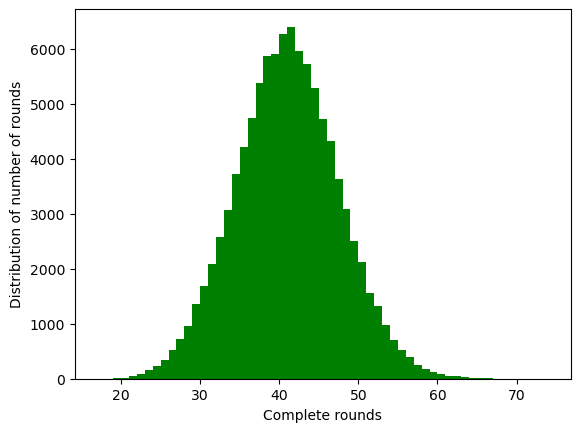

mu =  41.03820 +/-  0.02044
1/sigma =  0.15527 +/-  0.00035
A =  6182.57304 +/-  23.88925


In [17]:
plt.xlabel("Complete rounds")
plt.ylabel("Distribution of number of rounds")
n, bins, patches = plt.hist(all_rounds_played_for_winner,
                            bins=max(all_rounds_played_for_winner)-min(all_rounds_played_for_winner),
                            facecolor='green', density=False, log=False)
plt.show()

# The Gaussian is not normalized, so we add an amplitude degree of freedom
def gauss(x, m, s_inv, A):
    return A * np.exp(-0.5 * (s_inv * (x - m))**2)
    
# This time we also populate and use Poisson errors
x_data = np.array([(bins[i+1] + bins[i])*0.5 for i in range(n.shape[0])])
y_data = n
y_errs = np.sqrt(y_data)

# This will single out non-empty bins
mask = y_data > 0

fit_pars_errs, cov_matrix_errs = curve_fit(gauss, x_data[mask],
                                           y_data[mask],
                                           sigma=y_errs[mask],
                                           absolute_sigma=True,
                                           p0=[40., 1/6.5, 100])

[print(f"{param_labels[i]} = {fit_pars_errs[i]: .5f} +/- {np.sqrt(cov_matrix_errs[i,i]): .5f}") for i in range(len(fit_pars_errs))];

To be compared to the previous fit.

In [18]:
[print(f"{param_labels[i]} = {fit_pars[i]: .5f} +/- {np.sqrt(cov_matrix[i,i]): .5f}") for i in range(len(fit_pars))];

mu =  40.97366 +/-  0.02578
1/sigma =  0.15514 +/-  0.00051


This can be more interesting in terms of comparing $\sigma$'s, i.e., standard deviations from the fits.

In [19]:
s = 1/fit_pars[1]
ds = (1/fit_pars[1]**2)*np.sqrt(cov_matrix[1,1])

print(f"Without counting errors: sigma ={s: .5f} +/-{ds: .5f}")

s_errs = 1/fit_pars_errs[1]
ds_errs = (1/fit_pars_errs[1]**2)*np.sqrt(cov_matrix_errs[1,1])

print(f"With couinting errors: sigma ={s_errs: .5f} +/-{ds_errs: .5f}")

Without counting errors: sigma = 6.44558 +/- 0.02105
With couinting errors: sigma = 6.44038 +/- 0.01431


## Class for Kniffel

<img src="https://images.thalia.media/-/BF750-750/43abfdfb8d2d44bd9b16c16431310ff3/schmidt-spiele-kniffel.jpeg"  width=400 />

In [20]:
class Kniffel_Game:
    """
    Class to simulate how long a player needs to roll for 
    in order to complete all (special) goals in a Kniffel game
    
    Attributes
      1. `verbose`: regulate the verbosity of the output [bool]
    """

    verbose = False

    _game_round = 0
    
    _ks_set = set((1,2,3,4,5))
    _gs_set = set((2,3,4,5,6))
    
    def __init__(self, verbose=verbose):
        self.verbose = verbose
        if self.verbose:
            info = "Simulating a kniffel game played by 1 player.\n"
            info += "5 dice are used. No coins are involved.\n"
            print(info)
        self._die = Die()
        # The book-keeping of the special rolls that remain to be
        # achieved is regulated by progressively emptying out the
        # following dictionary (also used for verbose output)...
        self._remaining_events = {
            'ks': "Kleine strasse",
            'gs': "Grosse strasse",
            '3k': "Dreierpatsch",
            '4k': "Viererpatsch",
            'fh': "Full house",
            'kn': "Kniffel"
        }
        # ...with this dictionary of popping functions, where the key
        # is the number of different values shown by the dice roll
        self._update_remaining_events = {
            3: self._3_val_pop,
            5: self._5_val_pop,
            2: self._2_val_pop,
            1: self._1_val_pop
        }
    
    def __str__(self):
        info = f"Round {self._game_round} - Events remaining to be achieved: {list(self._remaining_events.values())}"
        return info
    
    def play_a_game(self):
        """
        Simulate the rolls of a Kniffel game to completion.
        """
        while len(self._remaining_events):
            self._game_round += 1
            self._hand = np.array([self._die.single_roll() for i in range(5)])
            # If the case has not been covered, len(set(self._hand) will be
            # a key of the dictionary; if it is not, we pass (via self.no_pop)
            self._update_remaining_events.get(len(set(self._hand)), self._no_pop)()
            if self.verbose:
                print(self)
        if self.verbose:
            print(f"Rounds played = {self._game_round}.\n")
        return self._game_round
    
    # The dice show 4 different values: no special combination
    def _no_pop(self):
        pass

    # The dice show 3 different values: the only interesting case
    # is when one of these appears 3 times, which is a 3-of-a-kind
    def _3_val_pop(self):
        _, counts = np.unique(self._hand, return_counts=True, )
        if 3 in counts:
            self._remaining_events.pop('3k', None)
            # We will no longer need to pop '3k'
            self._update_remaining_events.pop(3)

    # The dice show 5 different values: this presents two
    # interesting cases which are (1,2,3,4,5) and (2,3,4,5,6)
    def _5_val_pop(self):
        set_hand = set(self._hand)
        if set_hand == self._ks_set:
            self._remaining_events.pop('ks', None)
            if 'gs' not in self._remaining_events.keys():
                # We will no longer need to pop 'ks' or 'gs'
                self._update_remaining_events.pop(5)
        elif set_hand == self._gs_set:
            self._remaining_events.pop('gs', None)
            # We will no longer need to pop 'gs' or 'ks'
            if 'ks' not in self._remaining_events.keys():
                self._update_remaining_events.pop(5)
    
    # The dice show 2 different values: these can appear 2 and 3
    # times (full house) or 1 and 4 times (4-of-a-kind)
    def _2_val_pop(self):
        set_hand, counts = np.unique(self._hand, return_counts=True)
        if 4 in counts: #set_hand
            self._remaining_events.pop('4k', None)
            if 'fh' not in self._remaining_events.keys():
                # We will no longer need to pop '4k' or 'fh'
                self._update_remaining_events.pop(2)
            return
        self._remaining_events.pop('fh', None)
        if '4k' not in self._remaining_events.keys():
            # We will no longer need to pop 'fh' or '4k'
            self._update_remaining_events.pop(2)
    
    # Last possibility: the same value appears 5 times (kniffel)
    def _1_val_pop(self):
        self._remaining_events.pop('kn', None)
        # We will no longer need to pop 'kn'
        self._update_remaining_events.pop(1)

In [21]:
help(Kniffel_Game)

Help on class Kniffel_Game in module __main__:

class Kniffel_Game(builtins.object)
 |  Kniffel_Game(verbose=False)
 |
 |  Class to simulate how long a player needs to roll for
 |  in order to complete all (special) goals in a Kniffel game
 |
 |  Attributes
 |    1. `verbose`: regulate the verbosity of the output [bool]
 |
 |  Methods defined here:
 |
 |  __init__(self, verbose=False)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __str__(self)
 |      Return str(self).
 |
 |  play_a_game(self)
 |      Simulate the rolls of a Kniffel game to completion.
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object
 |
 |  ----------------------------------------------------------------------
 |  Data and other attributes defined here:
 |
 |  verbose = False



In [22]:
r.seed(1)
%timeit Kniffel_Game().play_a_game()

14.3 ms ± 1.3 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


#### `if` structuring in updating `_remaining_events`

We want to run as few `if` checks as possible, so we want to hit the conditions in order from the most common to the least common.

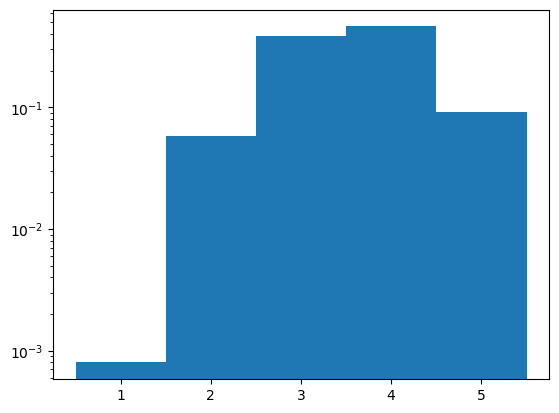

CPU times: user 49.2 s, sys: 1.54 s, total: 50.8 s
Wall time: 52.4 s


In [23]:
%%time

die = Die()

def acrue_stats(die):
    hand = np.array([die.single_roll() for i in range(5)])
    set_hand, counts = np.unique(hand, return_counts=True)
    return len(counts)

#r.seed(1)
Total_games = int(1e6)

all_lcounts = np.array([acrue_stats(die) for i in range(Total_games)])

n, bins, _ = plt.hist(all_lcounts, bins=(0.5,1.5,2.5,3.5,4.5,5.5), density=True, log=True)
plt.show()

We can see that the cases sorted by frequency have 4, 3, 5, 2, and 1 different values showing in the dice roll.

And here is what you would do to pythonize what is evident from an inspection of the graph.

In [24]:
freq = n
num_values = (bins+0.5)[:-1]
print(freq.shape, num_values.shape)

roll_stats = np.stack((num_values, freq)).transpose()
print(roll_stats)
print("Similar to:", list(zip(num_values, freq)))

answer = roll_stats[roll_stats[:, 1].argsort()][::-1][:,0]
print('Sorted by frequency:', answer)

(5,) (5,)
[[1.00000e+00 7.99000e-04]
 [2.00000e+00 5.78110e-02]
 [3.00000e+00 3.85516e-01]
 [4.00000e+00 4.63506e-01]
 [5.00000e+00 9.23680e-02]]
Similar to: [(1.0, 0.000799), (2.0, 0.057811), (3.0, 0.385516), (4.0, 0.463506), (5.0, 0.092368)]
Sorted by frequency: [4. 3. 5. 2. 1.]


### The actual simulation of `Total_games` Kniffel games

In [25]:
%%time

r.seed(1)
Total_games = int(1e4)

all_rounds_played_to_end = np.array([Kniffel_Game().play_a_game() for i in range(Total_games)])

CPU times: user 2min 35s, sys: 7.03 s, total: 2min 42s
Wall time: 2min 47s


### Plotting the distribution of the total rolls over the simulated games

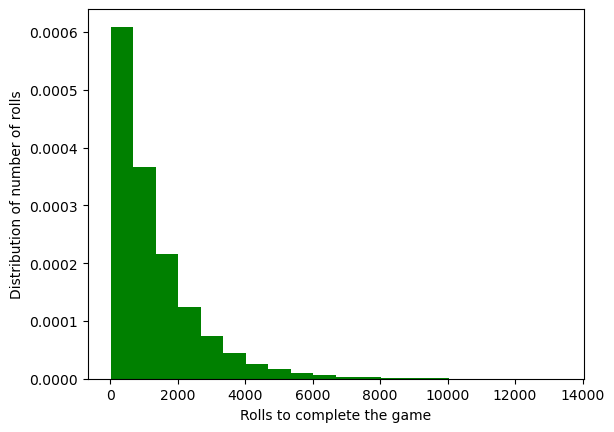

In [26]:
plt.xlabel("Rolls to complete the game")
plt.ylabel("Distribution of number of rolls")
n, bins, patches = plt.hist(
    all_rounds_played_to_end,
    bins=20,
    facecolor='green',
    density=True,
    log=False
)

This is an exponential decay distribution.  The expectation value is found with `curve_fit` and its corresponding Poisson distribution is overlayed to the histogram.

_We will use counting errors (Poisson errors) on the vertical axis: this time we normalize directly and go through the procedure just once.  Again, we take care of emtpy bins that would give vanish errors by ignoring them._

In [27]:
param_labels = ['lambda']

# Poisson distribution: the expectation value for the number of rolls is 1/lam
def Poisson(x, lam):
    return lam * np.exp(-lam*x)

x_data = np.array([(bins[i+1] + bins[i])*0.5 for i in range(n.shape[0])])
y_data = n
y_errs = np.sqrt(y_data/Total_games)

# Non empty bins 
mask = y_data > 0

fit_pars, cov_matrix = curve_fit(Poisson, x_data, y_data, [0.001])
fit_pars_errs, cov_matrix_errs = curve_fit(
    Poisson,
    x_data[mask],
    y_data[mask],
    sigma=y_errs[mask],
    absolute_sigma=True,
    p0=[0.001]
)

print(f"{param_labels[0]} = {fit_pars[0]: .5f} +/- {np.sqrt(cov_matrix[0,0]): .5f}")
print(f"{param_labels[0]} = {fit_pars_errs[0]: .5f} +/- {np.sqrt(cov_matrix_errs[0,0]): .5f}")

lambda =  0.00080 +/-  0.00001
lambda =  0.00078 +/-  0.00021


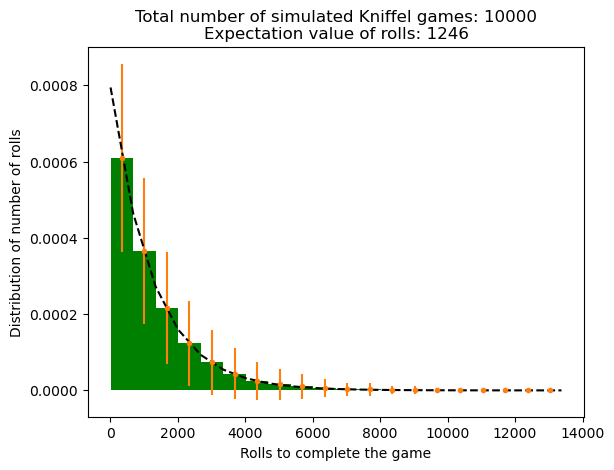

In [32]:
#lam = 0.78e-3 # Poisson distribution: the expectation value for the number of rolls is 1/lam
lam = fit_pars[0]
y = [Poisson(b, lam) for b in bins]

plt.xlabel("Rolls to complete the game")
plt.ylabel("Distribution of number of rolls")
title = f"Total number of simulated Kniffel games: {Total_games}\n"
title += f"Expectation value of rolls: {1/lam:.0f}"
plt.title(title)
n, bins, patches = plt.hist(
    all_rounds_played_to_end,
    bins=20,
    facecolor='green',
    density=True,
    log=False
)
plt.errorbar(
    x_data,
    y_data,
    yerr = y_errs,
    marker = '.',
    ls=''
)

plt.plot(bins, y, 'k--', linewidth=1.5, label='Theoretical')

plt.show()

Its log-linear version

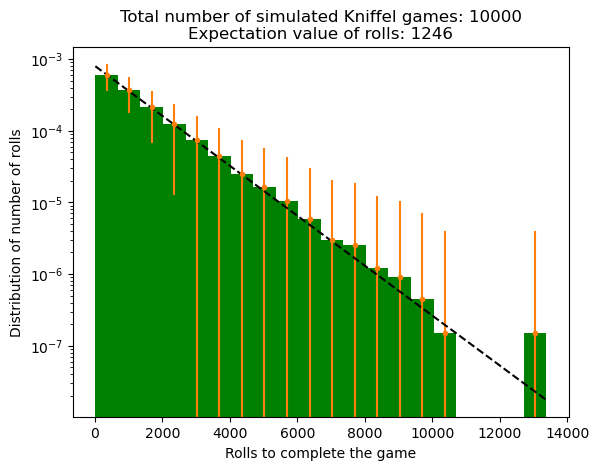

In [29]:
plt.xlabel("Rolls to complete the game")
plt.ylabel("Distribution of number of rolls")
plt.title(title)

n, bins, patches = plt.hist(
    all_rounds_played_to_end,
    bins=20,
    facecolor='green',
    density=True,
    log=True
)
plt.errorbar(
    x_data,
    y_data,
    yerr = y_errs,
    marker = '.',
    ls=''
)
   
plt.plot(bins, y, 'k--', linewidth=1.5, label='Theoretical')
plt.show()

The cumulative distribution

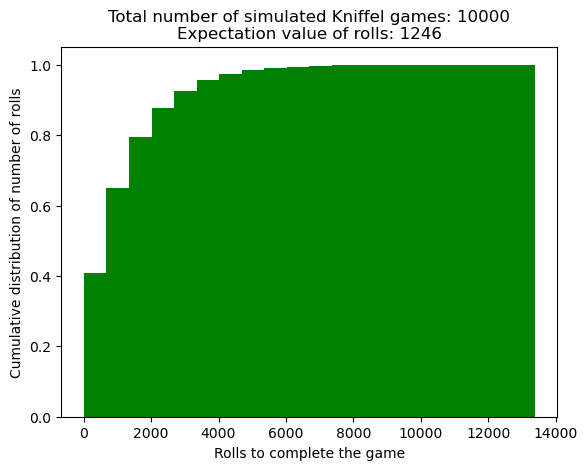

In [30]:
plt.xlabel("Rolls to complete the game")
plt.ylabel("Cumulative distribution of number of rolls")
plt.title(title)
n, bins, patches = plt.hist(
    all_rounds_played_to_end,
    bins=20,
    facecolor='green',
    density=True,
    log=False,
    cumulative=True
)

Its semilog version

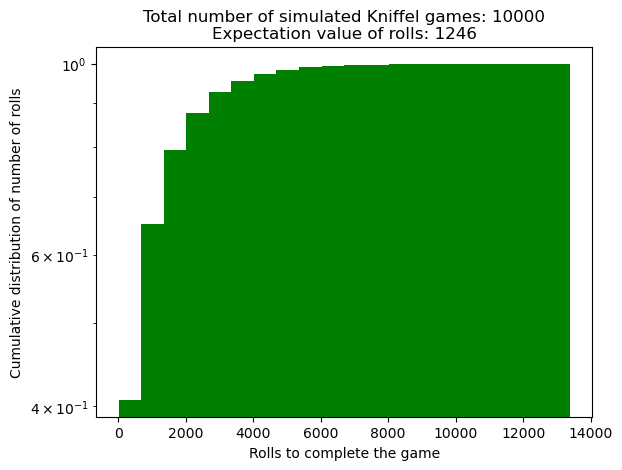

In [31]:
plt.xlabel("Rolls to complete the game")
plt.ylabel("Cumulative distribution of number of rolls")
plt.title(title)
n, bins, patches = plt.hist(
    all_rounds_played_to_end,
    bins=20,
    facecolor='green',
    density=True,
    log=True,
    cumulative=True
)